# Comparaison FinBERT / ground truth StockTwits

Les messages sans label natif ne sont pas assimilés à des messages neutres. L'évaluation supervisée porte uniquement sur les messages StockTwits explicitement marqués Bullish ou Bearish.

In [1]:
import os, glob, html, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score, f1_score

PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"
INFERENCE_PATH = os.path.join(PROJET, "data", "processed", "02_StockTwits_SCORED_2020_2022.csv")
BASE = os.path.join(PROJET, "data", "raw", "source_data_trouve_stocktwits", "StockTwits_2020_2022_Raw")
OUT_DIR = os.path.join(PROJET, "data", "processed")
FOLDERS = ["AAPL_2020_2022", "AMZN2019-2022", "FB_2019_2022", "NVDA_2013_2022", "TSLA_2020_2022"]
PANEL_T = {"AAPL", "AMZN", "META", "NVDA", "TSLA"}
sns.set_theme(style="whitegrid")
print(os.path.isfile(INFERENCE_PATH), os.path.isdir(BASE))

True True


## 1. Scores FinBERT

In [2]:
df_finbert = pd.read_csv(INFERENCE_PATH)
required = {"Tweet", "Ticker", "FinBERT_Positive", "FinBERT_Negative", "FinBERT_Neutral"}
missing = required.difference(df_finbert.columns)
if missing:
    raise ValueError(f"Colonnes manquantes : {sorted(missing)}")
prob_cols = ["FinBERT_Positive", "FinBERT_Negative", "FinBERT_Neutral"]
df_finbert["finbert_label"] = df_finbert[prob_cols].idxmax(axis=1).str.replace("FinBERT_", "", regex=False).str.lower()
df_finbert["finbert_confidence"] = df_finbert[prob_cols].max(axis=1)
print(f"Lignes FinBERT : {len(df_finbert):,}")
display((df_finbert["finbert_label"].value_counts(normalize=True) * 100).round(2).to_frame("pct"))

Lignes FinBERT : 3,711,333


,pct
finbert_label,
neutral,81.26
positive,12.43
negative,6.31


## 2. Labels natifs StockTwits

In [3]:
SYM_RE = re.compile(r"['\"]symbol['\"]\s*[:=]\s*['\"]([A-Z]+)['\"]")
CASHTAG_RE = re.compile(r"\$([A-Z]{1,5})\b")

def ticker_from_row(symbols, body):
    symbols = "" if pd.isna(symbols) else str(symbols)
    body = "" if pd.isna(body) else str(body)
    match = re.search(SYM_RE, symbols)
    ticker = match.group(1) if match else ""
    if not ticker:
        match = re.search(CASHTAG_RE, body.upper())
        ticker = match.group(1) if match else ""
    if ticker == "FB":
        ticker = "META"
    return ticker if ticker in PANEL_T else None

def native_label(value):
    if pd.isna(value):
        return None
    value = str(value)
    if re.search(r"['\"]basic['\"]\s*:\s*['\"]Bullish['\"]", value, re.I):
        return "positive"
    if re.search(r"['\"]basic['\"]\s*:\s*['\"]Bearish['\"]", value, re.I):
        return "negative"
    return None

parts = []
paths = []
for folder in FOLDERS:
    paths.extend(sorted(glob.glob(os.path.join(BASE, folder, "*.csv"))))
for path in paths:
    columns = pd.read_csv(path, nrows=0).columns
    needed = [c for c in ["body", "symbols", "entities"] if c in columns]
    part = pd.read_csv(path, usecols=needed)
    body = part.get("body", pd.Series("", index=part.index)).fillna("").astype(str)
    symbols = part.get("symbols", pd.Series("", index=part.index))
    entities = part.get("entities", pd.Series(index=part.index, dtype=object))
    part = pd.DataFrame({"Tweet": body, "Ticker": [ticker_from_row(s, b) for s, b in zip(symbols, body)], "native_label": entities.apply(native_label)})
    parts.append(part)
df_native = pd.concat(parts, ignore_index=True)
df_native = df_native[df_native["Ticker"].notna()].copy()
print(f"Lignes brutes : {len(df_native):,}")
display(df_native["native_label"].value_counts(dropna=False).to_frame("n"))

Lignes brutes : 4,322,378


,n
native_label,
None,2137775
positive,1638509
negative,546094


## 3. Fusion FinBERT / labels natifs

Le fichier FinBERT ne conserve pas l'identifiant StockTwits. La clé utilise le texte normalisé, le ticker et le rang d'occurrence des doublons.

In [4]:
def text_key(value):
    value = "" if pd.isna(value) else str(value)
    return re.sub(r"\s+", " ", html.unescape(value)).strip()

for frame in [df_finbert, df_native]:
    frame["Ticker"] = frame["Ticker"].replace({"FB": "META"})
    frame["Tweet_key"] = frame["Tweet"].map(text_key)
    frame["occurrence"] = frame.groupby(["Ticker", "Tweet_key"], dropna=False).cumcount()

df_compare = df_finbert.merge(df_native[["Ticker", "Tweet_key", "occurrence", "native_label"]], on=["Ticker", "Tweet_key", "occurrence"], how="left", validate="one_to_one")
matched = df_compare["native_label"].notna().sum()
print(f"Labels natifs retrouvés : {matched:,}/{len(df_compare):,} ({matched / len(df_compare) * 100:.2f}%)")

Labels natifs retrouvés : 1,934,860/3,711,333 (52.13%)


## 4. Évaluation, matrice de confusion et faux neutres

Observations évaluées : 1,934,860
              precision    recall  f1-score   support

    positive       0.87      0.15      0.25   1448748
    negative       0.49      0.11      0.18    486112
     neutral       0.00      0.00      0.00         0

    accuracy                           0.14   1934860
   macro avg       0.45      0.09      0.14   1934860
weighted avg       0.77      0.14      0.23   1934860



c:\Users\semy4\OneDrive\Bureau\Fintech_project\venv\lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Balanced accuracy : 0.1293
F1 macro : 0.1444
Cohen kappa : 0.0325


,FinBERT_positive,FinBERT_negative,FinBERT_neutral
Réel_positive,213006,56403,1179339
Réel_negative,31852,54238,400022
Réel_neutral,0,0,0


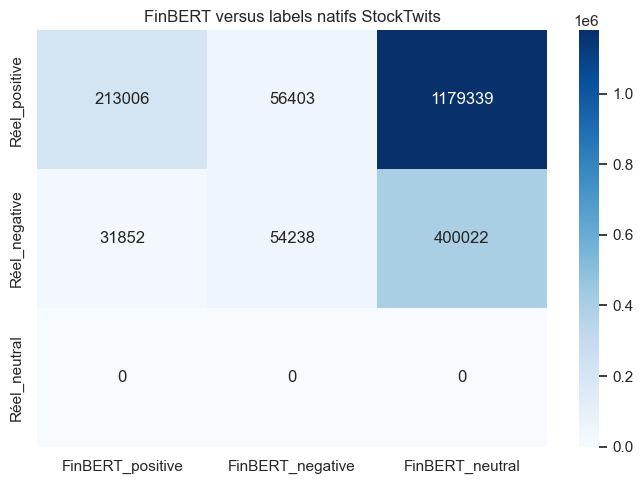

Faux neutres : 1,579,361 (81.63%)


,Ticker,Tweet,native_label,FinBERT_Positive,FinBERT_Negative,FinBERT_Neutral,finbert_confidence
0,AAPL,$AAPL good things happening 2020 run trump and...,positive,2.008633e-01,2.107586e-03,0.797029,0.797029
2,AAPL,Happy New Year :)\n$AAPL $TSLA $AMZN $SPY $B...,positive,7.078456e-05,1.083000e-05,0.999918,0.999918
6,AAPL,$AAPL gonna rip on Thursday for the new year,positive,1.401273e-06,1.680813e-05,0.999982,0.999982
10,AAPL,$AAPL Just got a lap dance from a v hot stripp...,positive,1.391241e-03,1.066597e-02,0.987943,0.987943
12,AAPL,$AAPL ALL TIME HIGH! \n$293.97 \nAll Time High...,positive,3.451359e-04,5.183325e-07,0.999654,0.999654
21,AAPL,$TSLA $AAPL two red days are coming 😢,negative,8.770294e-06,3.514825e-05,0.999956,0.999956
24,AAPL,$AAPL $SPY what I don’t understand is that if ...,positive,2.564901e-05,8.260209e-03,0.991714,0.991714
31,AAPL,@sonicmerlin $AAPL - looks like it&#39;s goi...,positive,2.119502e-02,5.045394e-04,0.978301,0.978301
32,AAPL,$AAPL,negative,3.236148e-04,2.840201e-05,0.999648,0.999648
38,AAPL,$AAPL . $300 next week!,positive,1.192781e-05,3.568076e-06,0.999985,0.999985


In [5]:
labels = ["positive", "negative", "neutral"]
df_labeled = df_compare[df_compare["native_label"].isin(["positive", "negative"])].copy()
if df_labeled.empty:
    raise ValueError("Aucun label Bullish/Bearish retrouvé.")
y_true = df_labeled["native_label"]
y_pred = df_labeled["finbert_label"]
print(f"Observations évaluées : {len(df_labeled):,}")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print(f"Balanced accuracy : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"F1 macro : {f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0):.4f}")
print(f"Cohen kappa : {cohen_kappa_score(y_true, y_pred):.4f}")
cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=[f"Réel_{x}" for x in labels], columns=[f"FinBERT_{x}" for x in labels])
display(cm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("FinBERT versus labels natifs StockTwits")
plt.tight_layout()
plt.show()

faux_neutres = df_labeled[df_labeled["finbert_label"] == "neutral"].copy()
print(f"Faux neutres : {len(faux_neutres):,} ({len(faux_neutres) / len(df_labeled) * 100:.2f}%)")
display(faux_neutres[["Ticker", "Tweet", "native_label"] + prob_cols + ["finbert_confidence"]].head(50))

## 5. Résultats par ticker et par confiance

In [6]:
rows = []
for ticker, group in df_labeled.groupby("Ticker"):
    rows.append({"Ticker": ticker, "n": len(group), "accord": (group["native_label"] == group["finbert_label"]).mean(), "f1_macro": f1_score(group["native_label"], group["finbert_label"], labels=labels, average="macro", zero_division=0), "faux_neutres": (group["finbert_label"] == "neutral").mean()})
by_ticker = pd.DataFrame(rows).sort_values("Ticker")
display(by_ticker.round(4))

confidence_rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    subset = df_labeled[df_labeled["finbert_confidence"] >= threshold]
    if len(subset) == 0:
        continue
    confidence_rows.append({"seuil": threshold, "n": len(subset), "couverture_pct": len(subset) / len(df_labeled) * 100, "accord": (subset["native_label"] == subset["finbert_label"]).mean(), "faux_neutres": (subset["finbert_label"] == "neutral").mean()})
display(pd.DataFrame(confidence_rows).round(4))

,Ticker,n,accord,f1_macro,faux_neutres
0,AAPL,449129,0.1800,0.1775,0.7636
1,AMZN,187197,0.1708,0.1682,0.7826
2,META,121619,0.1456,0.1491,0.8089
3,NVDA,106985,0.1965,0.1818,0.7486
4,TSLA,1069930,0.1081,0.1208,0.8519


,seuil,n,couverture_pct,accord,faux_neutres
0,0.50,1930257,99.7621,0.1377,0.8172
1,0.60,1896511,98.0180,0.1345,0.8231
2,0.70,1860261,96.1445,0.1313,0.8290
3,0.80,1815758,93.8444,0.1275,0.8357
4,0.90,1747518,90.3175,0.1222,0.8449
5,0.95,1682975,86.9817,0.1177,0.8526


## 6. Exports

In [7]:
df_compare.to_csv(os.path.join(OUT_DIR, "FINBERT_VS_STOCKTWITS_GROUND_TRUTH.csv"), index=False)
by_ticker.to_csv(os.path.join(OUT_DIR, "FINBERT_VS_STOCKTWITS_BY_TICKER.csv"), index=False)
pd.DataFrame(confidence_rows).to_csv(os.path.join(OUT_DIR, "FINBERT_VS_STOCKTWITS_CONFIDENCE.csv"), index=False)
print("Exports terminés dans", OUT_DIR)

Exports terminés dans C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed
